<a href="https://colab.research.google.com/github/nkr9/Data-Analyst/blob/main/EXPERIMENT_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> EXPERIMENT-6  </center>
# <center> IPL Analysis  </center>

## 1. Import required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

## 2. Load the data

In [ ]:
df= pd.read_csv('IPL IMB381IPL2013.csv')
df.head()

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00,...,0.00,0,307,15,20.47,8.90,13.93,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41,...,0.00,0,29,0,0.00,14.50,0.00,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62,...,121.01,5,1059,29,36.52,8.81,24.90,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56,...,76.32,0,1125,49,22.96,6.23,22.14,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93,...,120.71,28,0,0,0.00,0.00,0.00,2011,100000,800000


## 3. Take a look at the data and remove missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    object 
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    object 
 4   TEAM           130 non-null    object 
 5   PLAYING ROLE   130 non-null    object 
 6   T-RUNS         130 non-null    int64  
 7   T-WKTS         130 non-null    int64  
 8   ODI-RUNS-S     130 non-null    int64  
 9   ODI-SR-B       130 non-null    float64
 10  ODI-WKTS       130 non-null    int64  
 11  ODI-SR-BL      130 non-null    float64
 12  CAPTAINCY EXP  130 non-null    int64  
 13  RUNS-S         130 non-null    int64  
 14  HS             130 non-null    int64  
 15  AVE            130 non-null    float64
 16  SR-B           130 non-null    float64
 17  SIXERS         130 non-null    int64  
 18  RUNS-C    

In [ ]:
df = df.dropna()

## 4. Define dependent and Independent Variables

In [ ]:
df = df.drop(columns=['Sl.NO.','PLAYER NAME','TEAM']) # Features

## 5. Preprocess Categorical variables

In [ ]:
X_features = df.columns
X_features

Index(['AGE', 'COUNTRY', 'PLAYING ROLE', 'T-RUNS', 'T-WKTS', 'ODI-RUNS-S',
       'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S', 'HS',
       'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL', 'ECON', 'SR-BL',
       'AUCTION YEAR', 'BASE PRICE', 'SOLD PRICE'],
      dtype='object')

In [ ]:
pd.get_dummies(df['PLAYING ROLE'],dtype=int)[0:5]

,Allrounder,Batsman,Bowler,W. Keeper
0,1,0,0,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,1,0,0


In [ ]:
categorical_features = ['AGE', 'COUNTRY', 'PLAYING ROLE','CAPTAINCY EXP','PLAYING ROLE']
ipl_auction_encoded_df = pd.get_dummies(df[X_features],columns = categorical_features, dtype=int, drop_first = True)
ipl_auction_encoded_df.columns

Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
       'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE', 'SOLD PRICE', 'AGE_2',
       'AGE_3', 'COUNTRY_BAN', 'COUNTRY_ENG', 'COUNTRY_IND', 'COUNTRY_NZ',
       'COUNTRY_PAK', 'COUNTRY_SA', 'COUNTRY_SL', 'COUNTRY_WI', 'COUNTRY_ZIM',
       'PLAYING ROLE_Batsman', 'PLAYING ROLE_Bowler', 'PLAYING ROLE_W. Keeper',
       'CAPTAINCY EXP_1', 'PLAYING ROLE_Batsman', 'PLAYING ROLE_Bowler',
       'PLAYING ROLE_W. Keeper'],
      dtype='object')

In [ ]:
ipl_auction_encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   T-RUNS                  130 non-null    int64  
 1   T-WKTS                  130 non-null    int64  
 2   ODI-RUNS-S              130 non-null    int64  
 3   ODI-SR-B                130 non-null    float64
 4   ODI-WKTS                130 non-null    int64  
 5   ODI-SR-BL               130 non-null    float64
 6   RUNS-S                  130 non-null    int64  
 7   HS                      130 non-null    int64  
 8   AVE                     130 non-null    float64
 9   SR-B                    130 non-null    float64
 10  SIXERS                  130 non-null    int64  
 11  RUNS-C                  130 non-null    int64  
 12  WKTS                    130 non-null    int64  
 13  AVE-BL                  130 non-null    float64
 14  ECON                    130 non-null    fl

In [ ]:
ipl_auction_encoded_df = ipl_auction_encoded_df.loc[:, ~ipl_auction_encoded_df.columns.duplicated()]

In [ ]:
ipl_auction_encoded_df.columns

Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
       'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE', 'SOLD PRICE', 'AGE_2',
       'AGE_3', 'COUNTRY_BAN', 'COUNTRY_ENG', 'COUNTRY_IND', 'COUNTRY_NZ',
       'COUNTRY_PAK', 'COUNTRY_SA', 'COUNTRY_SL', 'COUNTRY_WI', 'COUNTRY_ZIM',
       'PLAYING ROLE_Batsman', 'PLAYING ROLE_Bowler', 'PLAYING ROLE_W. Keeper',
       'CAPTAINCY EXP_1'],
      dtype='object')

In [ ]:
X = sm.add_constant( ipl_auction_encoded_df )
Y = ipl_auction_encoded_df['SOLD PRICE']

## 6. Split the data into test and train set and plotting to visualize the train and test set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X ,Y, train_size = 0.8,random_state = 42 )

In [ ]:
print(X_train.dtypes)
print(X_train.select_dtypes(include='object').columns)

const                     float64
T-RUNS                      int64
T-WKTS                      int64
ODI-RUNS-S                  int64
ODI-SR-B                  float64
ODI-WKTS                    int64
ODI-SR-BL                 float64
RUNS-S                      int64
HS                          int64
AVE                       float64
SR-B                      float64
SIXERS                      int64
RUNS-C                      int64
WKTS                        int64
AVE-BL                    float64
ECON                      float64
SR-BL                     float64
AUCTION YEAR                int64
BASE PRICE                  int64
SOLD PRICE                  int64
AGE_2                       int32
AGE_3                       int32
COUNTRY_BAN                 int32
COUNTRY_ENG                 int32
COUNTRY_IND                 int32
COUNTRY_NZ                  int32
COUNTRY_PAK                 int32
COUNTRY_SA                  int32
COUNTRY_SL                  int32
COUNTRY_WI    

## 7. Building the Model on the Training Dataset

In [ ]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary2())

                          Results: Ordinary least squares
Model:                    OLS                   Adj. R-squared:          1.000     
Dependent Variable:       SOLD PRICE            AIC:                     -3920.6270
Date:                     2025-05-04 22:38      BIC:                     -3828.0734
No. Observations:         104                   Log-Likelihood:          1995.3    
Df Model:                 34                    F-statistic:             2.741e+29 
Df Residuals:             69                    Prob (F-statistic):      0.00      
R-squared:                1.000                 Scale:                   1.9108e-18
-----------------------------------------------------------------------------------
                        Coef.  Std.Err.           t           P>|t|   [0.025 0.975]
-----------------------------------------------------------------------------------
const                  -0.0000   0.0000               -0.0822 0.9347 -0.0000 0.0000
T-RUNS            

**Variance Inflation Factor (VIF)**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def get_vif_factors( X ):
    X_matrix = X.to_numpy()
    vif =  [variance_inflation_factor(X_matrix, i ) for i in range (X_matrix.shape[1]) ]
    vif_factors = pd.DataFrame()
    vif_factors['column'] = X.columns
    vif_factors['VIF'] = vif
    return vif_factors

In [ ]:
X_new_features= ipl_auction_encoded_df.columns

In [ ]:
vif_factors= get_vif_factors(X[X_new_features]) # the values more than 4 have multicollinearity

In [ ]:
columns_with_large_vif = vif_factors[vif_factors['VIF'] > 4].column

**Checking Correlation of Columns with Large VIFs**

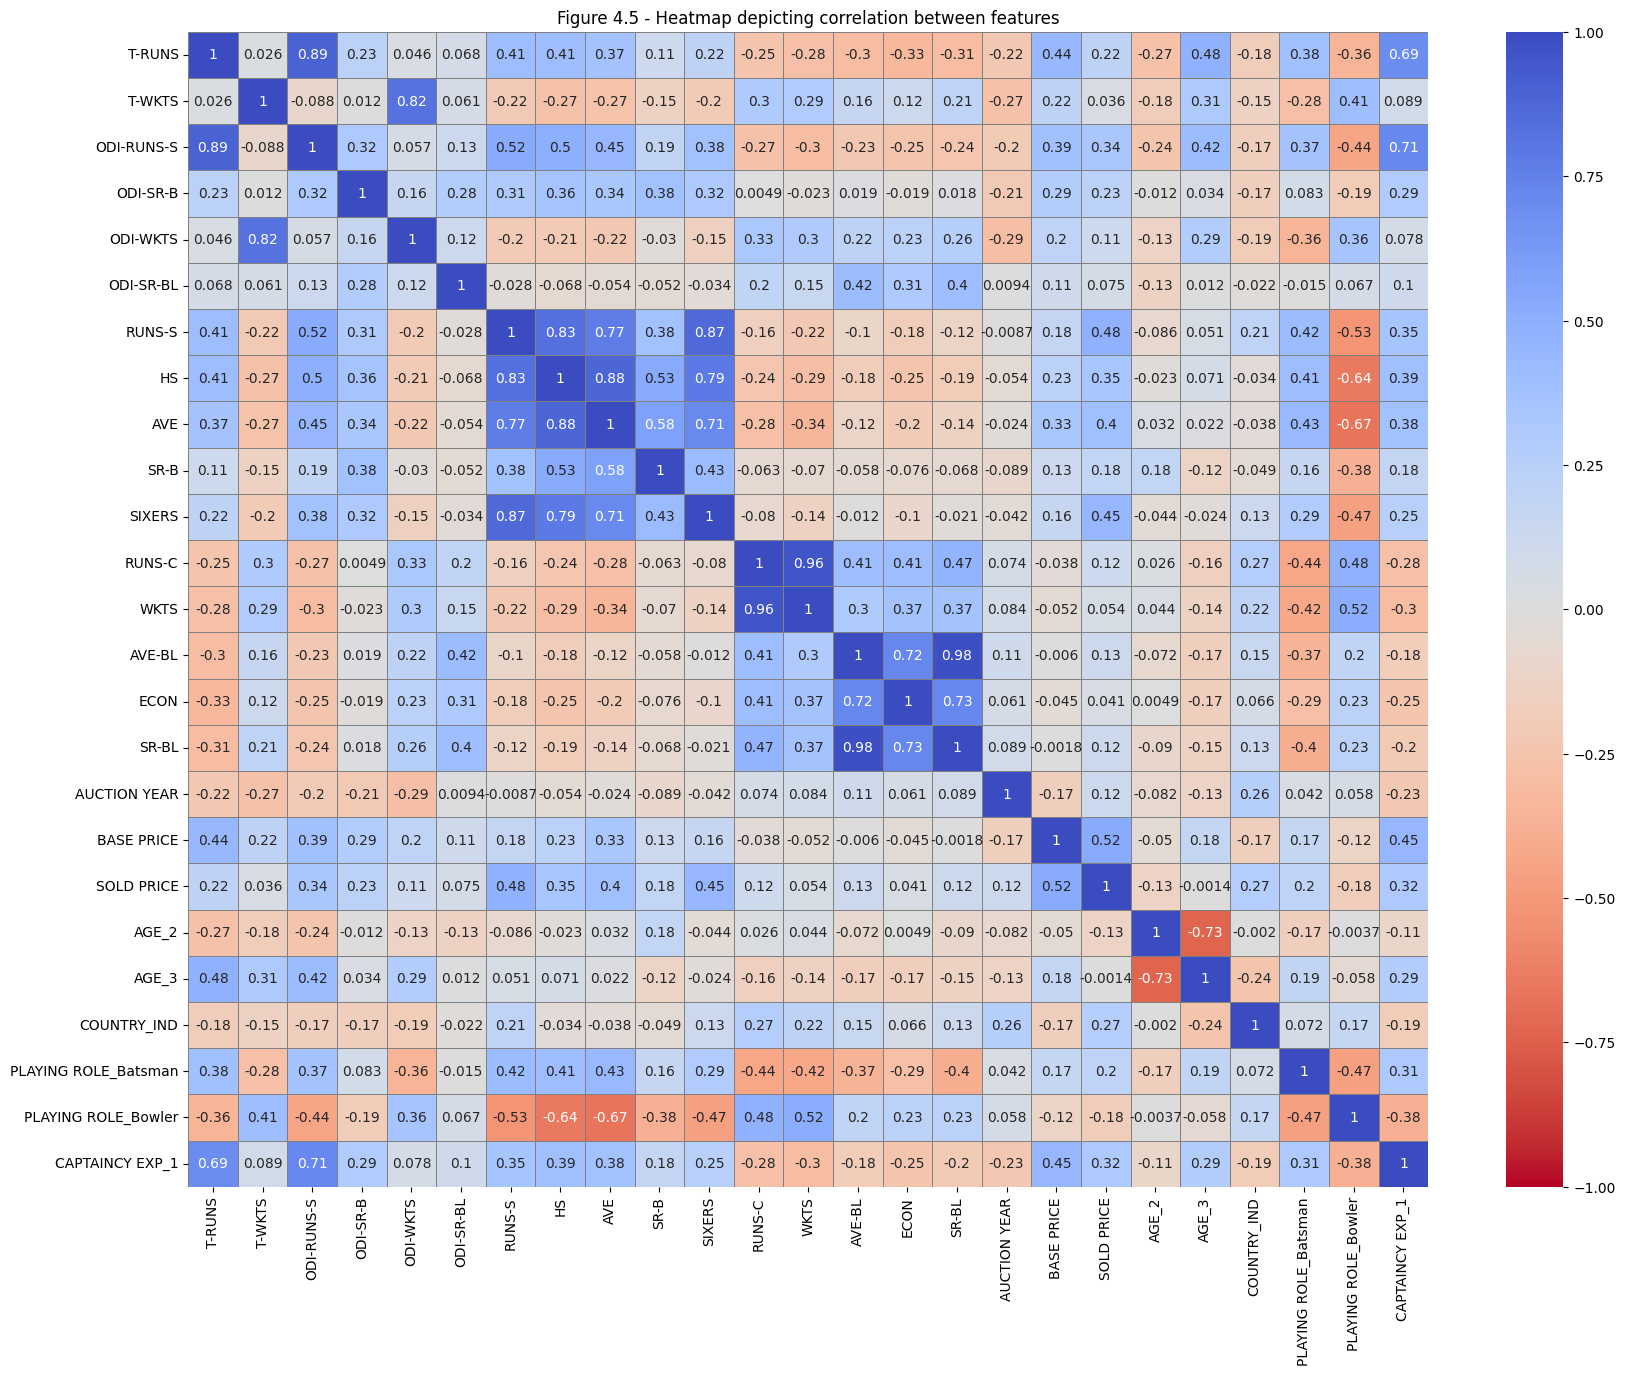

In [ ]:
plt.figure(figsize = (20,15) )
sns.heatmap( X[columns_with_large_vif].corr(), annot = True, cmap='coolwarm_r',center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='gray')
plt.title("Figure 4.5 - Heatmap depicting correlation between features")
plt.show()

In [ ]:
# dropping columns from df causing too much multicollinearity
columns_to_be_removed = ['T-RNS', 'T-TS', 'RNS-S', 'S', 'E',
                         'RUNS-C', 'SR-B', 'AVE-BL', 'ECON',
                         'DI-SR-', 'DI-RNS-S', 'E_2', 'SR-L']

In [ ]:
# Get only valid columns (intersection of X_features and X.columns)
valid_features = list(set(X_features) & set(X.columns))

# Drop multicollinear columns
columns_to_be_removed = ['T-RNS', 'T-TS', 'RNS-S', 'S', 'E',
                         'RUNS-C', 'SR-B', 'AVE-BL', 'ECON',
                         'DI-SR-', 'DI-RNS-S', 'E_2', 'SR-L']

# Final set of columns to use for VIF
X_new_features = list(set(valid_features) - set(columns_to_be_removed))

# Now safely call get_vif_factors
get_vif_factors(X[X_new_features])


,column,VIF
0,AVE,20.561050
1,T-WKTS,5.469307
2,BASE PRICE,5.717561
3,ODI-SR-B,12.665341
4,SIXERS,8.167521
5,ODI-RUNS-S,13.182171
6,RUNS-S,12.477524
7,SR-BL,3.784121
8,AUCTION YEAR,13.481160
9,T-RUNS,11.566344


**Building a New Model after Removing Multi-collinearity**

In [ ]:
train_X = X_train[X_new_features]
ipl_model_2 = sm.OLS(y_train, train_X).fit()
ipl_model_2.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 1.000     
Dependent Variable:     SOLD PRICE       AIC:                         -4247.0864
Date:                   2025-05-04 22:38 BIC:                         -4207.4205
No. Observations:       104              Log-Likelihood:              2138.5    
Df Model:               15               F-statistic:                 3.268e+31 
Df Residuals:           89               Prob (F-statistic):          0.00      
R-squared (uncentered): 1.000            Scale:                       9.4286e-20
---------------------------------------------------------------------------------
                Coef.   Std.Err.            t            P>|t|    [0.025   0.975]
---------------------------------------------------------------------------------
AVE            -0.0000    0.0000                -1.9336  0.0563  -0.0000   0.0000
T-WKTS          0.0000    0.0000                 2.3658  0.0202   0.0000   0.0000
BASE PRICE      0.0000    0.0000                 3.5433  0.0006   0.0000   0.0000
ODI-SR-B       -0.0000    0.0000                -1.0055  0.3174  -0.0000   0.0000
SIXERS         -0.0000    0.0000                -2.2279  0.0284  -0.0000  -0.0000
ODI-RUNS-S      0.0000    0.0000                 2.4888  0.0147   0.0000   0.0000
RUNS-S          0.0000    0.0000                 1.9374  0.0559  -0.0000   0.0000
SR-BL          -0.0000    0.0000                -0.4511  0.6530  -0.0000   0.0000
AUCTION YEAR    0.0000    0.0000                 2.1397  0.0351   0.0000   0.0000
T-RUNS         -0.0000    0.0000                -1.3246  0.1887  -0.0000   0.0000
HS              0.0000    0.0000                 0.6293  0.5307  -0.0000   0.0000
WKTS            0.0000    0.0000                 1.7504  0.0835  -0.0000   0.0000
SOLD PRICE      1.0000    0.0000  8985538268046615.0000  0.0000   1.0000   1.0000
ODI-WKTS       -0.0000    0.0000                -1.1748  0.2432  -0.0000   0.0000
ODI-SR-BL      -0.0000    0.0000                -0.7632  0.4473  -0.0000   0.0000
--------------------------------------------------------------------------------
Omnibus:                   9.235             Durbin-Watson:               1.316 
Prob(Omnibus):             0.010             Jarque-Bera (JB):            9.597 
Skew:                      -0.578            Prob(JB):                    0.008 
Kurtosis:                  3.936             Condition No.:               155448
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
[3] The condition number is large, 1.55e+05. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

In [ ]:
significant_vars = ['COUNTRY_IND', 'COUNTRY_ENG', 'SIXERS', 'CAPTAINCY EXP_1']
X_train = X_train[significant_vars]
ipl_model_3 = sm.OLS(y_train, X_train).fit()
ipl_model_3.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.741     
Dependent Variable:     SOLD PRICE       AIC:                         1527.9999 
Date:                   2025-05-04 22:53 BIC:                         1538.5775 
No. Observations:       104              Log-Likelihood:              -760.00   
Df Model:               4                F-statistic:                 75.29     
Df Residuals:           100              Prob (F-statistic):          2.63e-29  
R-squared (uncentered): 0.751            Scale:                       1.3550e+05
-----------------------------------------------------------------------------------
                    Coef.      Std.Err.      t       P>|t|      [0.025      0.975] 
-----------------------------------------------------------------------------------
COUNTRY_IND        490.7089     63.9238    7.6765    0.0000    363.8860    617.5318
COUNTRY_ENG        563.0261    217.2801    2.5912    0.0110    131.9486    994.1036
SIXERS               8.5338      1.6995    5.0213    0.0000      5.1620     11.9055
CAPTAINCY EXP_1    417.7575     76.0204    5.4953    0.0000    266.9352    568.5799
--------------------------------------------------------------------------------
Omnibus:                   0.017             Durbin-Watson:                1.879
Prob(Omnibus):             0.992             Jarque-Bera (JB):             0.145
Skew:                      0.005             Prob(JB):                     0.930
Kurtosis:                  2.817             Condition No.:                165  
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
"""

**Residual Analysis in Multiple Linear Regression
1. Test for Normality of Residuals (P-P Plot)

<Figure size 800x600 with 0 Axes>

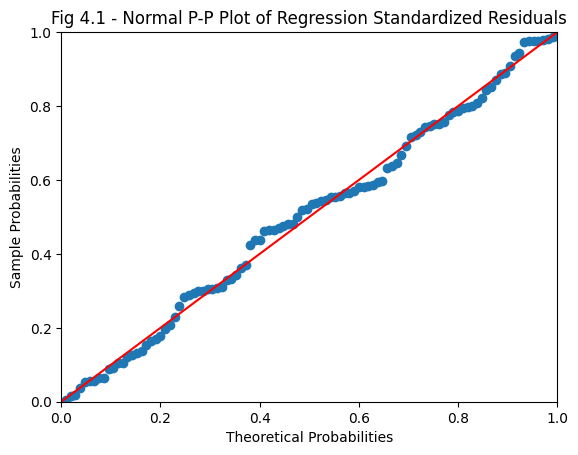

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

def draw_pp_plot_scaled(model, title):
    """
    Draws a Normal P-P Plot of standardized residuals from a regression model.

    Parameters:
    - model: A fitted regression model (e.g., from statsmodels OLS)
    - title: Title for the plot
    """
    # Standardize residuals
    scaler = StandardScaler()
    standardized_resid = scaler.fit_transform(model.resid.values.reshape(-1, 1)).flatten()

    # Create and display the P-P plot
    probplot = sm.ProbPlot(standardized_resid)
    plt.figure(figsize=(8, 6))
    probplot.ppplot(line='45')
    plt.title(title)
    plt.show()
draw_pp_plot_scaled(
    ipl_model_3,
    "Fig 4.1 - Normal P-P Plot of Regression Standardized Residuals"
)



2. Detecting Influencers

In [ ]:
k= X_train.shape[1]
n = X_train.shape[0]

leverage_cutoff = 3*((k+ 1)/n)
print('Cutoff for leverage value:', round(leverage_cutoff, 3) )

Cutoff for leverage value: 0.144


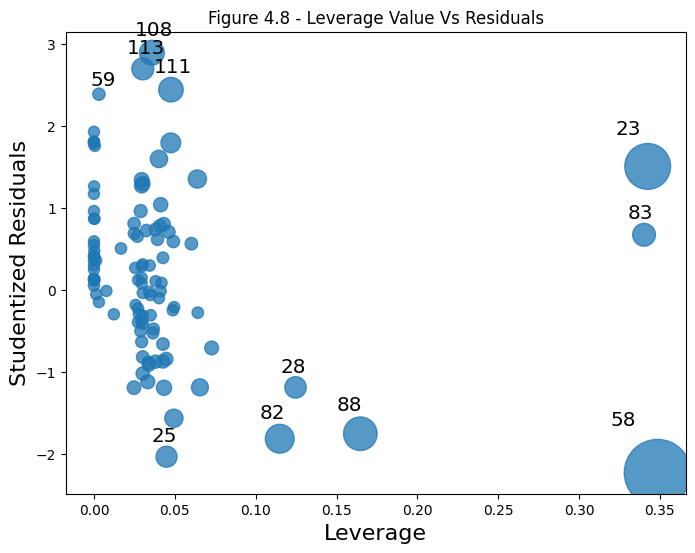

In [ ]:
from statsmodels.graphics.regressionplots import influence_plot
fig, ax = plt.subplots( figsize=(8,6) )
influence_plot(ipl_model_3, ax = ax )
plt.title( "Figure 4.8 - Leverage Value Vs Residuals" )
plt.show()

In [ ]:
train_X_new = X_train.drop([2, 58, 8], axis = 0)
train_y_new = y_train.drop([2, 58, 8], axis = 0)

4. Transforming Response Variable

In [ ]:
y_train = np.sqrt(y_train)
ipl_model_4 = sm.OLS(y_train, X_train).fit()
ipl_model_4.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.741     
Dependent Variable:     SOLD PRICE       AIC:                         1527.9999 
Date:                   2025-05-04 22:38 BIC:                         1538.5775 
No. Observations:       104              Log-Likelihood:              -760.00   
Df Model:               4                F-statistic:                 75.29     
Df Residuals:           100              Prob (F-statistic):          2.63e-29  
R-squared (uncentered): 0.751            Scale:                       1.3550e+05
-----------------------------------------------------------------------------------
                    Coef.      Std.Err.      t       P>|t|      [0.025      0.975] 
-----------------------------------------------------------------------------------
COUNTRY_IND        490.7089     63.9238    7.6765    0.0000    363.8860    617.5318
COUNTRY_ENG        563.0261    217.2801    2.5912    0.0110    131.9486    994.1036
SIXERS               8.5338      1.6995    5.0213    0.0000      5.1620     11.9055
CAPTAINCY EXP_1    417.7575     76.0204    5.4953    0.0000    266.9352    568.5799
--------------------------------------------------------------------------------
Omnibus:                   0.017             Durbin-Watson:                1.879
Prob(Omnibus):             0.992             Jarque-Bera (JB):             0.145
Skew:                      0.005             Prob(JB):                     0.930
Kurtosis:                  2.817             Condition No.:                165  
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
"""

<Figure size 800x600 with 0 Axes>

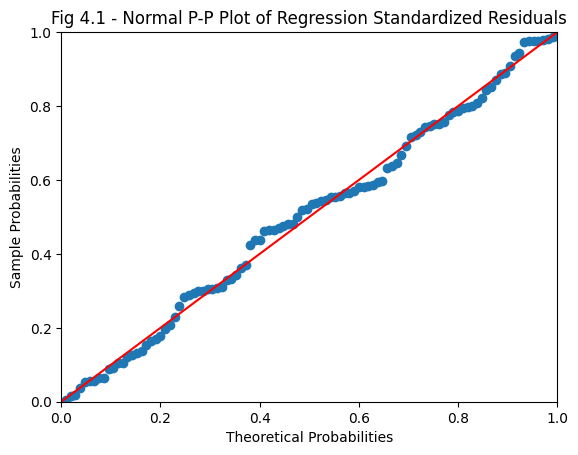

In [ ]:
draw_pp_plot_scaled(
    ipl_model_4,
    "Fig 4.1 - Normal P-P Plot of Regression Standardized Residuals"
)


## Make prediction on the validation set

In [ ]:
pred_y = np.power(ipl_model_4.predict(X_test[X_train.columns]),2)

**Measuring RMSE**

In [ ]:
from sklearn import metrics
np.sqrt(metrics.mean_squared_error(pred_y, y_test))

In [ ]:
np.round(metrics.r2_score(pred_y, y_test), 2 )

.
.
.
.
.
.
.
.
.
.
.
.
